In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

In [ ]:
import torch
from train.config import loadRunConfig, resolveDevice, resolveTarget, runConfigToDict
from train.evolve import EvolutionController

runConfig = loadRunConfig("configs/evo.yaml")
target = resolveTarget(runConfig)
device, dtype = resolveDevice(runConfig)

controller = EvolutionController(
    config=runConfig.evolution,
    targetSpec=target,
    arraySpec=runConfig.array,
    lossParams=runConfig.loss,
    experimentName=runConfig.experiment.name,
    archiveRoot=runConfig.experiment.archiveDir,
    loggingConfig=runConfig.logging,
    checkpointConfig=runConfig.checkpoint,
    workerConfig=runConfig.workers,
    targetMode=runConfig.experiment.targetMode,
    sourceConfigPath=runConfig.sourcePath,
    resolvedConfig=runConfigToDict(runConfig),
    writerLogDir=runConfig.experiment.logDir,
)

controller.train(
    dtype=dtype,
    device=device,
    logDir=runConfig.experiment.logDir,
    plotProjection=runConfig.experiment.plotProjection,
    resume=runConfig.experiment.resume,
)

Experiment: evo_v2_flashier_uniform_2
Best step: 61163
Best score: 0.05855095013976097


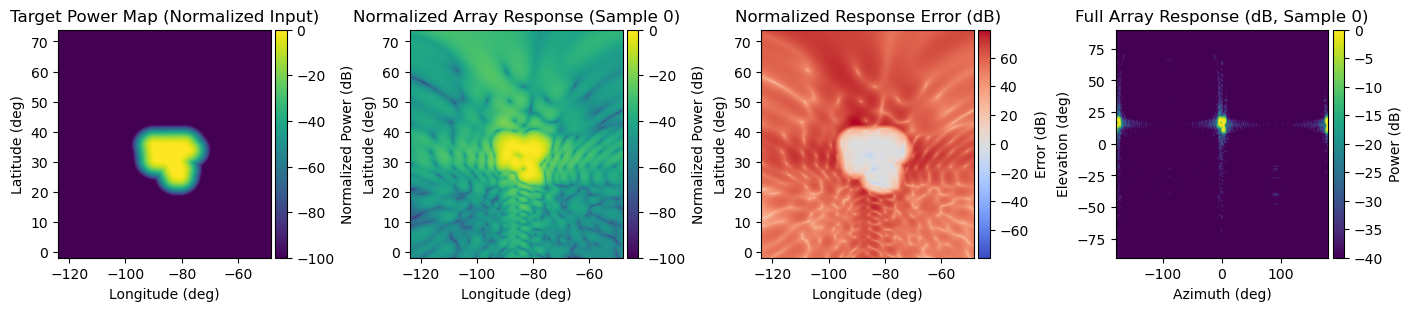

In [ ]:
from pathlib import Path
import torch
from scripts.arrayBatch import ArrayBatch
from scripts.plots import projectResponseOnTarget
from train.config import loadRunConfig, resolveDevice, resolveTarget

experiment = "evo_v3_multi"

run_config_path = Path("data/runs/evolution") / experiment / "config.yaml"
run_config = loadRunConfig(run_config_path)
target = resolveTarget(run_config)

config_device, dtype = resolveDevice(run_config)
device = config_device
if device.type == "cuda" and not torch.cuda.is_available():
    device = torch.device("cpu")

archive_dir = Path(run_config.experiment.archiveDir) / run_config.experiment.name
final_path = archive_dir / "final2.pt"
best_path = archive_dir / "best.pt"

sample_payload = None
summary = None

if final_path.exists():
    summary = torch.load(final_path, map_location="cpu", weights_only=False)
    sample_payload = summary.get("bestSampleOverall")

if sample_payload is None and best_path.exists():
    sample_payload = torch.load(best_path, map_location="cpu", weights_only=False)

if sample_payload is None:
    raise FileNotFoundError(f"No best sample found in {archive_dir}")

def batch_from_saved_sample(sample: dict) -> ArrayBatch:
    return ArrayBatch(
        elementLocalPosition=sample["elementLocalPosition"].unsqueeze(0),
        weights=sample["weights"].unsqueeze(0),
        wavelength=sample["wavelength"],
        gain=sample["gain"].reshape(1),
        LLAPosition=sample["LLAPosition"].unsqueeze(0),
        ECEFPosition=sample["ECEFPosition"].unsqueeze(0),
        elementMask=None if sample["elementMask"] is None else sample["elementMask"].unsqueeze(0),
    )

best_batch = batch_from_saved_sample(sample_payload).to(device)
target = target.to(device, dtype)

print(f"Experiment: {run_config.experiment.name}")
print(f"Best step: {sample_payload.get('step', None)}")
print(f"Best score: {sample_payload.get('score', None)}")

projectResponseOnTarget(
    batch=best_batch,
    target=target,
    sampleID=0,
    normalizedInputs=True,
)

